<a href="https://colab.research.google.com/github/Vidito/kristiania_python/blob/main/FinishedCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Final Exam Code
- This code was written on Google Colab to make collaboration easier, and the script was shared on our github repo available at https://github.com/Vidito/kristiania_python.

- The output for each task can be seen on the Colab or the Github repository.

- We tried to comment the code to explain why we have made those choices, even if it may seem too much redundant explanation and unnatural in the real world, yet for the sake of the exam and showing that we understood the code, we tried to give our reasoning.

- We tried to follow best practices such as using docstrings for functions and classes as well as function and class naming conventions.

- We also tried to use try/except to handle errors although that was not in the requirements.


##**Task 1: Redaction**

This program asks the user for three file names: one containing regular text
and one containing a list of sensitive words.
It then replaces all occurrences of the sensitive words in the text
with asterisks and saves the result to a third file,
where the sensitive words are concealed.

In [ ]:
def read_file_safely(prompt):
    """ asks the user for a filename to read and returns file content """
    while True:
        # ask the user to enter the filename specified in the prompt.
        filename = input(prompt)
        try:
            # attempt to open the file in read mode with UTF-8 encoding.
            # if the file exists, it will be opened successfully.
            with open(filename, "r", encoding="utf-8") as f:
                # return the entire content of the file.
                return f.read()
        except FileNotFoundError:
            # if the file cannot be found, inform the user and start the loop again.
            print(f"File '{filename}' not found. Please try again.\n")

# read the original text file (function repeats until a valid filename is provided).
txt = read_file_safely("Enter the name of the original text file: ")
# to check the contents in the console
print(f"Original Text: {txt}\n")

# read the sensitive words file (again, the user is prompted until a valid file is entered).
words_text = read_file_safely("Enter the name of the sensitive words file: ")


# this line creats a clean list of sensitive words by splitting the file by lines,
# removing extra spaces, and ignoring any empty lines.
# we use List Comprehension instead of For loop
sensitive_words = [line.strip() for line in words_text.split("\n") if line.strip()]
# to check the contents in the console
print(f"Sensitive Words: {words_text}\n")

# ask the user for the name of the output file that will store the redacted text.
redacted_file_name = input("Enter the name of the redacted file: ")

# replace each sensitive word in the original text.
for w in sensitive_words:
    # each word is replaced by '*' repeated according to its length.
    txt = txt.replace(w, "*" * len(w))


# create) the output file in write mode and write the redacted text into it.
with open(redacted_file_name, "w", encoding="utf-8") as f:
    f.write(txt)

# to check the contents in the console
print(f"Redacted Text: {txt}")

# inform the user that the process is complete.
print("\nRedacted file created successfully.")

Enter the name of the original text file: original.txt
Original Text: Vahid, Oleksi, and Emma are working on a secret project called "Kristiania Operation".
Their password is VEMO.

Enter the name of the sensitive words file: sensitive_words.txt
Sensitive Words: Kristiania Operation
VEMO

Enter the name of the redacted file: redacted.txt
Redacted Text: Vahid, Oleksi, and Emma are working on a secret project called "********************".
Their password is ****.

Redacted file created successfully.


## **Task 2: Inheritance**

This code defines a general Person class and two specialized classes: Student and Employee. All people share common details like first name, last name and age, while each subclass adds its own specific attributes.


In [ ]:
class Person:
    """base class that stores common personal information"""

    def __init__(self, fname, lname, age):
        self.fname = fname
        self.lname = lname
        self.age = age

    def get_info(self):
        """print full name and age for a person"""
        print("Full Name:", self.fname, self.lname)
        print("Age:", self.age)


class Student(Person):
    """student class that inherits from Person and adds a student ID"""

    def __init__(self, fname, lname, age, student_ID):
        # use super() to initialize attributes inherited from Person
        super().__init__(fname, lname, age)
        self.student_ID = student_ID  # student-specific attribute

    def get_stuinfo(self):
        """print all student information, including inherited details"""
        # first print the common personal information
        self.get_info()
        # then print the student-specific detail
        print("Student ID:", self.student_ID)


class Employee(Person):
    """employee class that inherits from Person and adds employee number and salary"""

    def __init__(self, fname, lname, age, employee_number, salary):
        # reuse Person's initializer for shared attributes
        super().__init__(fname, lname, age)
        self.employee_number = employee_number  # unique identifier for the employee
        self.salary = salary  # employee's monthly salary

    def get_empinfo(self):
        """print all employee information, including inherited details"""
        # print the basic personal information using Person's method
        self.get_info()
        # then print details specific to Employee
        print("Employee No:", self.employee_number)
        print("Salary:", self.salary, "USD")


# create a Student object and display its information
new_student = Student("Anthony", "Smith", 35, "s346571")
new_student.get_stuinfo()
print("="*30)

# create an Employee object and display its information
new_employee = Employee("Sarah", "Taylor", 34, 2919736, 5000)
new_employee.get_empinfo()

Full Name: Anthony Smith
Age: 35
Student ID: s346571
Full Name: Sarah Taylor
Age: 34
Employee No: 2919736
Salary: 5000 USD


## **Task 3: Banking System**
This program implements a simple text-based banking system using two classes: Menu and BankAccount. It lets the user open an account, deposit and withdraw money, add interest, check the balance, and quit via a looped menu.


In [ ]:
class Menu:
    def __init__(self):
        # an empty list for the options
        self.options = []

    def add_option(self, option):
        # append each option the user adds to the options list
        self.options.append(option)

    def get_input(self):
        # we used enumerate function to get the index (from 1) and the option in the list
        for index, option in enumerate(self.options, 1):
            print(f"{index}: {option}")
        # a while loop to make sure the user corrects its mistakes
        while True:
            try:
                print('-'*40)
                choice = int(input(f"Enter choice (1-{len(self.options)}): "))
                print('-'*40)
                # we make sure the number is within range by using chained comparison instead of AND
                if 1 <= choice <= len(self.options):
                    return choice
                print("Choice out of range.")
            except ValueError:
                print("Please enter a number.")


class BankAccount:
    def __init__(self):
        # initializing balance as zero when the account is created
        self.balance = 0.0

    def deposit(self, amount):
        try:
            # make sure amount is of type float
            amount = float(amount)
            if amount <= 0:
                print("Invalid deposit amount. Amount must be greater than zero.")
                return
            self.balance += amount
            print(f"Deposited {amount}kr. New balance: {self.balance}kr")
        except ValueError:
            print("Invalid input. Please enter a numeric amount.")

    def withdraw(self, amount):
        try:
            # make sure amount is float
            amount = float(amount)
            if amount <= 0:
                print("Invalid withdrawal amount. Must be greater than zero.")
                return
            # check to see if the requested amount is more than balance
            if amount > self.balance:
                print("Insufficient funds!")
            else:
                self.balance -= amount
                print(f"Withdrew {amount}kr. New balance: {self.balance}kr")
        except ValueError:
            print("Invalid input. Please enter a numeric amount.")

    def add_interest(self):
        # we assume a fixed 0.1 percent interest rate
        interest = self.balance * 0.001
        self.balance += interest
        print(f"Added interest: {interest}. New balance: {self.balance}kr")

    def get_balance(self):
        print(f"Current balance: {self.balance}kr")




In [ ]:
# instantiating menu so we can add options
menu = Menu()
menu.add_option("Open a new account")
menu.add_option("Deposit money into your account")
menu.add_option("Withdraw money from your account")
menu.add_option("Add interests to your account")
menu.add_option("Get the current balance of your account")
menu.add_option("Quit")




In [ ]:
# a helper function to avoid repeating printing style
def print_formatted_output(output):
    print("\n" + "*" * 40)
    print(output)
    print("\n" + "*" * 40)

account = None  # initialize account so we can check existence

while True:
    choice = menu.get_input()

    # validate choice range
    if choice not in range(1, len(menu.options) + 1):
        print_formatted_output("Invalid choice. Try again.")
        continue

    if choice == 1:
        # check if account exists
        if account:
            print_formatted_output("Account already exists")
        else:
          # instantiate the object (creating an account)
            account = BankAccount()
            print_formatted_output("New account opened!")

    elif choice == 2:
        if account:
            try:
                amount = input("Enter amount to deposit: ")
                print("\n" + "*" * 40)
                # method already handles number validation
                account.deposit(amount)
                print("\n" + "*" * 40)
            except ValueError:
                print_formatted_output("Invalid input. Please enter a number.")
        else:
            print_formatted_output("You need to create an account first!")

    elif choice == 3:
        if account:
            try:
                amount = float(input("Enter amount to withdraw: "))
                print("\n" + "*" * 40)
                account.withdraw(amount)
                print("\n" + "*" * 40)
            except ValueError:
                print_formatted_output("Invalid input. Please enter a number.")
        else:
            print_formatted_output("You need to create an account first!")

    elif choice == 4:
        if account:
            print("\n" + "*" * 40)
            account.add_interest()
            print("\n" + "*" * 40)

        else:
            print_formatted_output("You need to create an account first!")

    elif choice == 5:
        if account:
            print("\n" + "*" * 40)
            account.get_balance()
            print("\n" + "*" * 40)
        else:
            print_formatted_output("You need to create an account first!")

    elif choice == 6:
        print_formatted_output("Ha det bra!!")
        break

    else:
        print_formatted_output("Invalid choice. Try again.")


1: Open a new account
2: Deposit money into your account
3: Withdraw money from your account
4: Add interests to your account
5: Get the current balance of your account
6: Quit
----------------------------------------
Enter choice (1-6): 1
----------------------------------------

****************************************
New account opened!

****************************************
1: Open a new account
2: Deposit money into your account
3: Withdraw money from your account
4: Add interests to your account
5: Get the current balance of your account
6: Quit
----------------------------------------
Enter choice (1-6): 2
----------------------------------------
Enter amount to deposit: 1000

****************************************
Deposited 1000.0kr. New balance: 1000.0kr

****************************************
1: Open a new account
2: Deposit money into your account
3: Withdraw money from your account
4: Add interests to your account
5: Get the current balance of your account
6: Quit
-

## **Task 4: Sets and Strings**

This script analyzes two strings and identifies shared, unique, and missing alphabet characters. Although not mentioned in the task we decided to include sorted(), because the example output appeared to be sorted.

In [ ]:
def shared_characters(str1, str2):
    # find characters that appear in both strings
    set1 = set(str1)
    set2 = set(str2)
    # using intersection() to get elements common to both sets, but we also considered a for loop
    shared = set1.intersection(set2)
    return sorted(shared)

def unique_characters(str1, str2):
    # find characters that appear in only one of the strings
    set1 = set(str1)
    set2 = set(str2)
    # symmetric_difference() returns elements that are in one set but not both
    unique = set1.symmetric_difference(set2)
    return sorted(unique)

def non_occurring_letters(str1, str2):
    # find letters a–z that do not appear in either of the strings
    alphabet = set('abcdefghijklmnopqrstuvwxyz')
    set1 = set(str1.lower())
    set2 = set(str2.lower())
    # combine all characters from both input strings
    combined = set1.union(set2)
    # difference() gives letters that exist in alphabet but not in combined
    non_occurring = alphabet.difference(combined)
    return sorted(non_occurring)


# take user input for both strings
str1 = input("Enter the first string: ")
str2 = input("Enter the second string: ")

# print shared characters
print("\nShared characters:")
print(', '.join(shared_characters(str1, str2)))

# print characters unique to either string
print("\nUnique characters")
print(', '.join(unique_characters(str1, str2)))

# print alphabet letters that are not present in either string
print("\nNon-occurring alphabet letters:")
print(', '.join(non_occurring_letters(str1, str2)))


Enter the first string: Python
Enter the second string: Programming

Shared characters:
P, n, o

Unique characters
a, g, h, i, m, r, t, y

Non-occurring alphabet letters:
b, c, d, e, f, j, k, l, q, s, u, v, w, x, z


## **Task 5: Data Analysis and Visualization**
This script analyzes city data using pandas by selecting, filtering, and augmenting information in a DataFrame. It also visualizes population and area relationships with bar and scatter plots for clearer comparison.


Here is the dataframe for city_info dictionary: 
       State  Population    Area
0       Oslo      650000  450000
1     Bergen      320000  240000
2  Stavanger      150000  310000
3  Trondheim       90000  360000
----------------------------------------------------------------------
Here are the State and Population columns: 
       State  Population
0       Oslo      650000
1     Bergen      320000
2  Stavanger      150000
3  Trondheim       90000
----------------------------------------------------------------------
Here are rows for Oslo and Stavanger: 
       State  Population    Area
0       Oslo      650000  450000
2  Stavanger      150000  310000
----------------------------------------------------------------------
       State  Population
2  Stavanger      150000
3  Trondheim       90000
----------------------------------------------------------------------
DataFrame including Population Density:
       State  Population    Area  Population Density
0       Oslo      650000  4

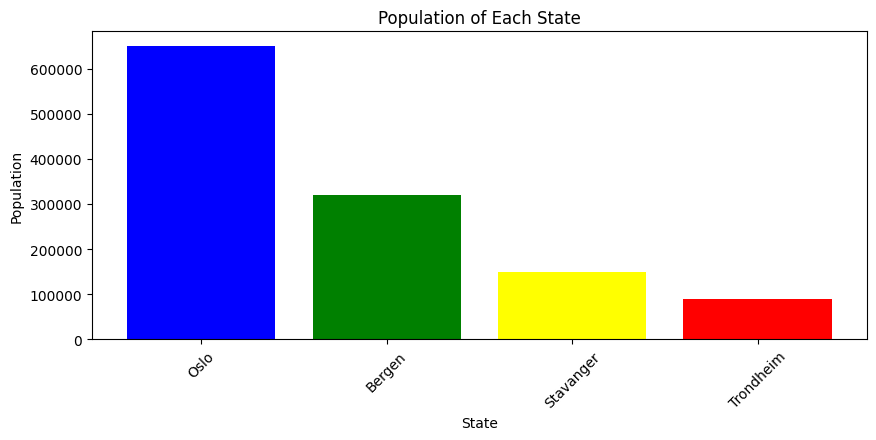

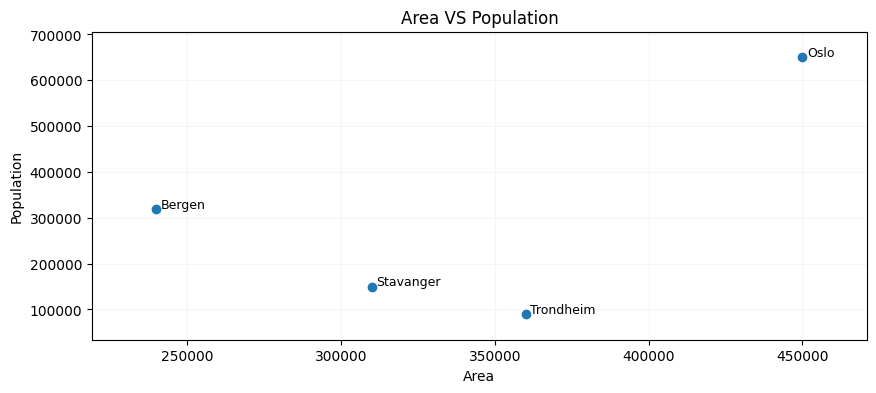

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# a. convert the dictionary city_info into a pandas DataFrame.
city_info = {
    'State': ['Oslo', 'Bergen', 'Stavanger', 'Trondheim'],
    'Population': [650000, 320000, 150000, 90000],
    'Area': [450000, 240000, 310000, 360000]
}


city_info_df = pd.DataFrame(city_info)
print("Here is the dataframe for city_info dictionary: ")
print(city_info_df)
print('-'*70)

# b.  select and print the columns "State" and "Population"
print("Here are the State and Population columns: ")
print(city_info_df[['State', 'Population']])
print('-'*70)

# c. select and print the rows corresponding to "Oslo" and "Stavanger"
# for the sake of clarity I saved the result in another df instead of passing the long expression directly in the print fucntion
oslo_stavanger = city_info_df.loc[(city_info_df['State'] == 'Oslo') | (city_info_df['State'] == 'Stavanger')]
print("Here are rows for Oslo and Stavanger: ")
print(oslo_stavanger)
print('-'*70)

# d. find the states where the population is smaller than 200000
# first I find the rows where poulation < 200000 and then select state and population values
print(city_info_df.loc[city_info_df['Population'] < 200000, ['State', 'Population']])
print('-'*70)

# e. add a new column "Population Density", calculated as Population / Area
city_info_df['Population Density'] = city_info_df['Population'] / city_info_df['Area']
print("DataFrame including Population Density:")
print(city_info_df)
print('-'*70)

# f. find the state with the highest population density
# I used idxmax method to get index for the row with highest population density
max_density_row = city_info_df.loc[city_info_df['Population Density'].idxmax()]
# then we can get the values for State and Population Density for that row
highest_density_state = max_density_row['State']
highest_density_value = max_density_row['Population Density']
print("Here is the State with highest population density: ")
print(f"State: {highest_density_state} - Density: {highest_density_value:.2f}")
print('-'*70)


# g. compute the average area and the average population of all states
avg_area = city_info_df['Area'].mean()
avg_population = city_info_df['Population'].mean()
print("Here are the average area and population of all states: ")
print(f"Average area: {avg_area}")
print(f"Average population: {avg_population}")
print('-'*70)

# h. draw a bar chart showing the population of each state.
# I just added some colors, and rotated the titles to lok nicer
plt.figure(figsize=(10, 4))
state_x = city_info_df['State']
population_y = city_info_df['Population']
colors = ['blue', 'green', 'yellow', 'red']
plt.bar(state_x, population_y, color=colors)
plt.title('Population of Each State')
plt.xlabel('State')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.show()

# i. scatter plot with Area on the x-axis and Population on the y-axis. Label the points with the state names.
plt.figure(figsize=(10, 4))
plt.scatter(city_info_df['Area'], city_info_df['Population'])
# labeling with plt.text(x, y, text, fontsize), we could also do it with plt.annotate() but different parameters
for i in range(len(city_info_df)):
    plt.text(
        city_info_df['Area'][i] + 1500,        # shift x slightly
        city_info_df['Population'][i] + 1500,  # shift y slightly
        city_info_df['State'][i],
        fontsize=9
    )
plt.title('Area VS Population')
plt.xlabel('Area')
plt.ylabel('Population')
# add 10% margin around chart since Oslo is close to the corner
plt.margins(x=0.1, y=0.1)
# adding the grid for better visbility and alpha to adjust visibility
plt.grid(True, alpha=0.1)
plt.show()

